# **Pré-processamento**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importação de bibliotecas
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
# Caminhos dos diretórios
base_path = "/content/drive/MyDrive/2025/Estudos/Datasets/hwu_usp"
ambient_path = os.path.join(base_path, "ambient_sensors")
inertial_path = os.path.join(base_path, "inertial_units")


In [4]:
# Lista de atividades
activities = sorted(os.listdir(ambient_path))

In [5]:
# Dicionário para armazenar os dados
data = []

In [6]:
def extract_id_person(file_name):
    id_str = file_name.split('_')[1].split('.')[0]  # Ex: "s01"
    if id_str.startswith("s") and id_str[1:].isdigit():
        return id_str[1:]  # retorna "01"
    else:
        raise ValueError(f"Formato inesperado de id_person em: {file_name}")

In [7]:
# Função para carregar os dados e organizar
def load_data():
    for activity in activities:
        ambient_files = sorted(os.listdir(os.path.join(ambient_path, activity)))
        inertial_files = sorted(os.listdir(os.path.join(inertial_path, activity)))

        for i in range(len(ambient_files)):
            ambient_file = os.path.join(ambient_path, activity, ambient_files[i])
            inertial_file = os.path.join(inertial_path, activity, inertial_files[i])

            ambient_df = pd.read_csv(ambient_file)
            inertial_df = pd.read_csv(inertial_file)

            ambient_df['activity'] = activity
            inertial_df['activity'] = activity

            id_person = extract_id_person(ambient_files[i])

            ambient_df = ambient_df.drop(columns=['activity'])
            inertial_df = inertial_df.drop(columns=['activity', 'id_person'], errors='ignore')

            combined_data = pd.concat([ambient_df, inertial_df], axis=1)
            combined_data['activity'] = activity
            combined_data['id_person'] = id_person

            data.append(combined_data)


In [8]:
# Carregar os dados
load_data()

In [9]:
# Converter para DataFrame
df = pd.concat(data, ignore_index=True)

print("Formato final dos dados:", df.shape)

Formato final dos dados: (334423, 27)


In [10]:
# Função para aplicar Sliding Window e capturar id_person
def create_sliding_windows(df, window_size=50, step=3):
    X, y, ids = [], [], []
    total_windows = 0

    for person_id in df['id_person'].unique():
        person_df = df[df['id_person'] == person_id]

        print(f"\n Processando pessoa: {person_id}")

        for activity in person_df['activity'].unique():
            activity_df = person_df[person_df['activity'] == activity]
            activity_data = activity_df.drop(columns=['activity', 'id_person']).values
            activity_labels = activity_df['activity'].values

            if len(activity_data) < window_size:
                print(f"   Atividade '{activity}' tem apenas {len(activity_data)} amostras. Pulando...")
                continue

            count = 0
            for i in range(0, len(activity_data) - window_size, step):
                X.append(activity_data[i:i+window_size])
                y.append(activity_labels[i + window_size - 1])
                ids.append(f"{int(person_id):02d}")
                count += 1

            print(f" Atividade '{activity}': {count} janelas geradas")
            total_windows += count

    if total_windows == 0:
        print("\n Nenhuma janela foi gerada! Verifique o tamanho da janela ou os dados de entrada.")
    else:
        print(f"\nTotal de janelas geradas: {total_windows}")

    return np.array(X), np.array(y), np.array(ids)


In [11]:
print(df.columns)


Index(['timestep', 'Ktch_B1_Draw', 'Ktch_B2_Cupboard', 'Ktch_B3_Cupboard',
       'Ktch_B4_Cupboard', 'Ktch_Motion_1', 'Ktch_Motion_2',
       'Ktch_T1_Cupboard', 'Ktch_T2_Cupboard', 'Ktch_T3_Cupboard',
       'Ktch_T4_Cupboard', 'TP_L_Power', 'timestep', 'waist_acc_x',
       'waist_acc_y', 'waist_acc_z', 'waist_gyro_x', 'waist_gyro_y',
       'waist_gyro_z', 'wrist_acc_x', 'wrist_acc_y', 'wrist_acc_z',
       'wrist_gyro_x', 'wrist_gyro_y', 'wrist_gyro_z', 'activity',
       'id_person'],
      dtype='object')


In [12]:
# CÉLULA 12: Separação dos dados originais por id_person ANTES do Sliding Window
train_ids = [f"{i:02d}" for i in range(1, 9)]  # Subjects 01 to 08 for Training
val_ids = [f"{i:02d}" for i in range(9, 11)]   # Subjects 09 and 10 for Validation
test_ids = [f"{i:02d}" for i in range(11, 17)] # Subjects 11 to 16 for Testing

df_train = df[df['id_person'].isin(train_ids)].copy()
df_val = df[df['id_person'].isin(val_ids)].copy()
df_test = df[df['id_person'].isin(test_ids)].copy()

print("Formato originais - Treino:", df_train.shape, "| Validação:", df_val.shape, "| Teste:", df_test.shape)

# Aplicar Sliding Window (2.5 segundos = 125 amostras, Overlap 50% = 62)
X_train, y_train, ids_train = create_sliding_windows(df_train, window_size=125, step=62)
X_val, y_val, ids_val = create_sliding_windows(df_val, window_size=125, step=62)
X_test, y_test, ids_test = create_sliding_windows(df_test, window_size=125, step=62)

print("\nFormato janelas - Treino:", X_train.shape, "| Validação:", X_val.shape, "| Teste:", X_test.shape)

Formato originais - Treino: (172789, 27) | Validação: (39030, 27) | Teste: (122604, 27)

 Processando pessoa: 01
 Atividade 'cereals': 36 janelas geradas
 Atividade 'dishes': 32 janelas geradas
 Atividade 'laptop': 21 janelas geradas
 Atividade 'newspaper': 19 janelas geradas
 Atividade 'sandwich': 55 janelas geradas
 Atividade 'smartphone': 22 janelas geradas
 Atividade 'table': 16 janelas geradas
 Atividade 'tea': 40 janelas geradas
 Atividade 'tidy': 21 janelas geradas

 Processando pessoa: 02
 Atividade 'cereals': 48 janelas geradas
 Atividade 'dishes': 40 janelas geradas
 Atividade 'laptop': 23 janelas geradas
 Atividade 'newspaper': 23 janelas geradas
 Atividade 'sandwich': 37 janelas geradas
 Atividade 'smartphone': 20 janelas geradas
 Atividade 'table': 16 janelas geradas
 Atividade 'tea': 41 janelas geradas
 Atividade 'tidy': 26 janelas geradas

 Processando pessoa: 03
 Atividade 'cereals': 61 janelas geradas
 Atividade 'dishes': 40 janelas geradas
 Atividade 'laptop': 23 jane

In [13]:
# CÉLULA 13/14/15 COMBINADA: Encoding, Scaling e Salvamento

# 1. Encode Labels
activity_labels = {activity: i for i, activity in enumerate(df['activity'].unique())}
y_train = np.array([activity_labels[label] for label in y_train])
y_val = np.array([activity_labels[label] for label in y_val])
y_test = np.array([activity_labels[label] for label in y_test])

# 2. Normalização (Fit apenas no treino!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# 3. Salvar Otimizado
OUTPUT_PATH = "/content/drive/MyDrive/2025/Estudos/Datasets/hwu_usp/hwu_usp_windowed_data_v2.npz"

np.savez_compressed(
    OUTPUT_PATH,
    X_train=X_train.astype(np.float32),
    X_val=X_val.astype(np.float32),
    X_test=X_test.astype(np.float32),
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)

print(f"Sucesso! Dados HWU-USP salvos em: {OUTPUT_PATH}")

Sucesso! Dados HWU-USP salvos em: /content/drive/MyDrive/2025/Estudos/Datasets/hwu_usp/hwu_usp_windowed_data_v2.npz


 **Análise Exploratória**

Distribuição de classes (atividades)

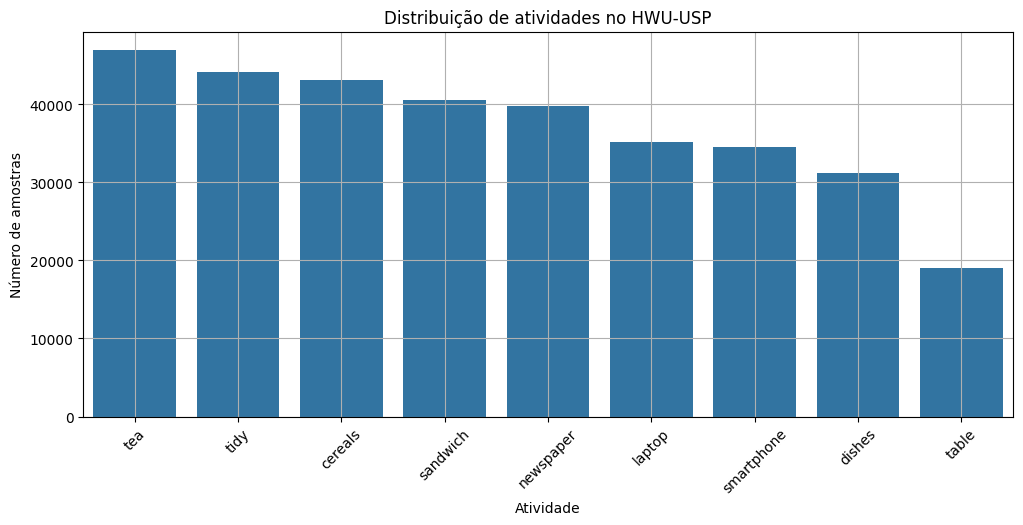

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(x='activity', data=df, order=df['activity'].value_counts().index)
plt.title("Distribuição de atividades no HWU-USP")
plt.xlabel("Atividade")
plt.ylabel("Número de amostras")
plt.xticks(rotation=45)
plt.grid()
plt.show()


Visualização de uma série temporal de sensor

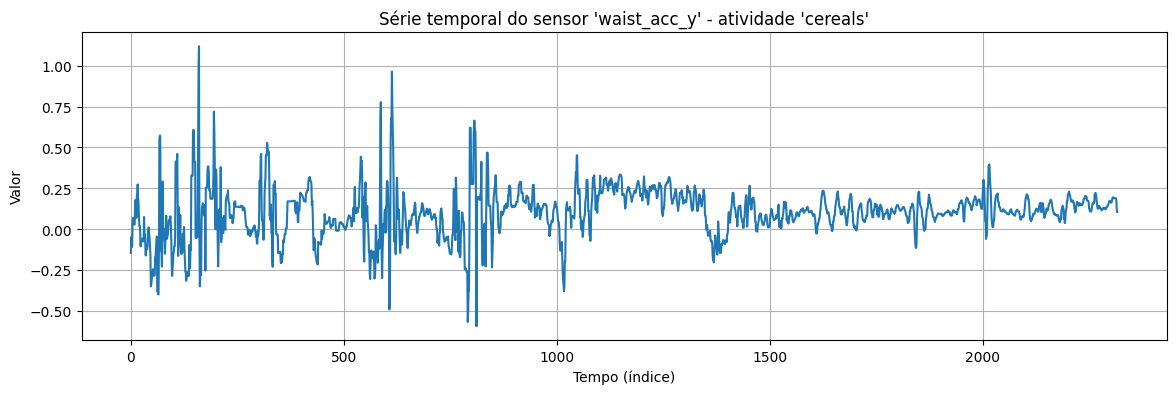

In [15]:
# Selecionar um sensor e uma atividade
sensor_col = df.columns[14]  # ir trocando o indice para ver os sensores (inicia em 1)
atividade = df['activity'].unique()[0]

# Amostras de uma atividade e uma pessoa
amostra = df[(df['activity'] == atividade) & (df['id_person'] == df['id_person'].unique()[0])]

# Plot da série temporal
plt.figure(figsize=(14,4))
plt.plot(amostra[sensor_col].values)
plt.title(f"Série temporal do sensor '{sensor_col}' - atividade '{atividade}'")
plt.xlabel("Tempo (índice)")
plt.ylabel("Valor")
plt.grid()
plt.show()


Histograma da Série e Transformações

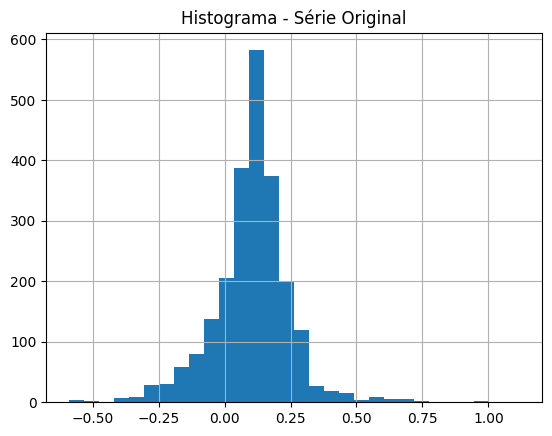

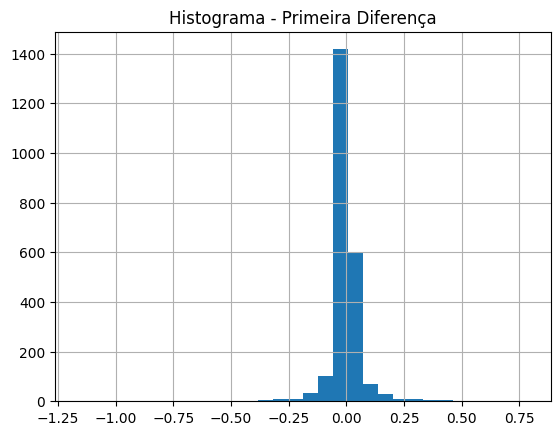

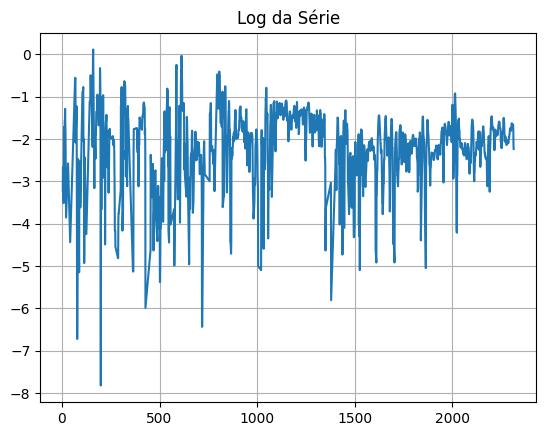

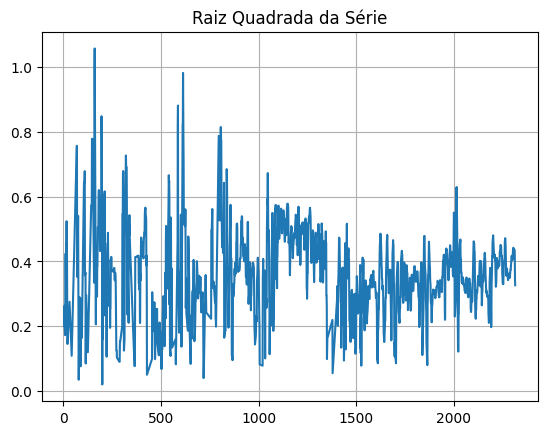

In [16]:
serie = amostra[sensor_col].dropna()

# Histograma original
plt.figure()
plt.hist(serie, bins=30)
plt.title('Histograma - Série Original')
plt.grid()
plt.show()

# Primeira diferença
diff = serie.diff().dropna()
plt.figure()
plt.hist(diff, bins=30)
plt.title('Histograma - Primeira Diferença')
plt.grid()
plt.show()

# Log
log_serie = np.log(serie[serie > 0])
log_serie.plot(title='Log da Série')
plt.grid()
plt.show()

# Raiz quadrada
sqrt_serie = np.sqrt(serie[serie >= 0])
sqrt_serie.plot(title='Raiz Quadrada da Série')
plt.grid()
plt.show()

Autocorrelação (ACF e PACF)

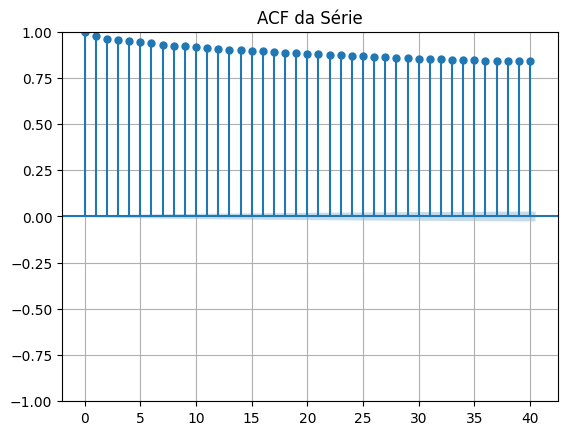

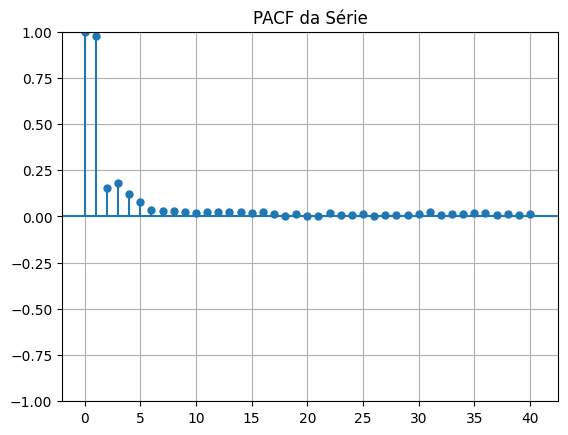

In [17]:
# Analisar a coluna 'waist_acc_z'
serie = df['waist_acc_z'].dropna()  # Isso deve ser uma Series 1D

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF
plot_acf(serie, lags=40)
plt.title('ACF da Série')
plt.grid()
plt.show()

# PACF
plot_pacf(serie, lags=40)
plt.title('PACF da Série')
plt.grid()
plt.show()
